---

# Concept Explanation 

## The Problem with LSTM

Even though LSTM improved things:

It still:

* Compresses the whole sentence into **one vector (hidden state)**
* Struggles with long sentences

---

### Example:

```python
"The movie that I watched yesterday with my friend was not good"
```

Important word = **"not"**

LSTM might lose it
(because it's far from the start)

---

## Key Idea of Attention

> Instead of compressing everything → look at ALL words and decide importance

---

## Intuition

Attention gives:
**different weights to different words**

---

### Example:

Sentence:

```python
"I did not like this movie"
```

Attention might assign:

```python
"I"      → 0.1  
"did"    → 0.1  
"not"    → 0.6   ** The Important word** 
"like"   → 0.1  
"movie"  → 0.1  
```

Model focuses on **"not"**

---

# Why It Matters

Without attention:

* Model depends only on memory 

With attention:

* Model can directly focus on important words

---

This leads to:

* Better performance
* Better long-range understanding
* Foundation of **Transformers**

---

# Simple Example

Reading:

```python
"The food was not very good"
```

Your brain:

* Ignores unimportant words
* Focuses on **"not"**

---

Attention = “smart focus”

---

You can inspect:

* Which words got higher importance

---

# Limitations

- Still depends on LSTM
- Sequential → slow
- Not fully parallelizable

---

# Mini Summary

* Attention assigns importance to words
* Solves long-distance dependency problem
* Works with LSTM to improve performance
* Foundation of Transformers

---

# Connection to Previous Notebook

* Before: LSTM → tries to remember everything
* Now: Attention → focuses on important parts

---

# Import libraries

In [1]:
import torch
import torch.nn as nn

# Attention Layer

In [3]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):

        scores = self.attn(lstm_output)  

        weights = torch.softmax(scores, dim=1)

        context = torch.sum(weights * lstm_output, dim=1)

        return context, weights

# LSTM + Attention

In [4]:
class LSTMAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.attention = Attention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)

        context, weights = self.attention(lstm_out)

        out = self.fc(context)
        out = self.sigmoid(out)

        return out, weights

In [6]:
sentences = [
    "i love nlp",
    "i hate bugs",
    "nlp is fun",
    "bugs are annoying"
]

labels = [1, 0, 1, 0]

words = set(" ".join(sentences).split())
word2idx = {word: i for i, word in enumerate(words)}

def encode(sentence):
    return [word2idx[word] for word in sentence.split()]

encoded = [torch.tensor(encode(s)) for s in sentences]
from torch.nn.utils.rnn import pad_sequence
padded = pad_sequence(encoded, batch_first=True)

labels = torch.tensor(labels).float().unsqueeze(1)

In [7]:
model = LSTMAttentionModel(
    vocab_size=len(word2idx),
    embed_dim=8,
    hidden_dim=16
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
losses = []

for epoch in range(100):
    outputs, _ = model(padded)  
    
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.5525
Epoch 20, Loss: 0.2279
Epoch 30, Loss: 0.0498
Epoch 40, Loss: 0.0121
Epoch 50, Loss: 0.0052
Epoch 60, Loss: 0.0032
Epoch 70, Loss: 0.0024
Epoch 80, Loss: 0.0019
Epoch 90, Loss: 0.0016
Epoch 100, Loss: 0.0014


# Visualization / Results

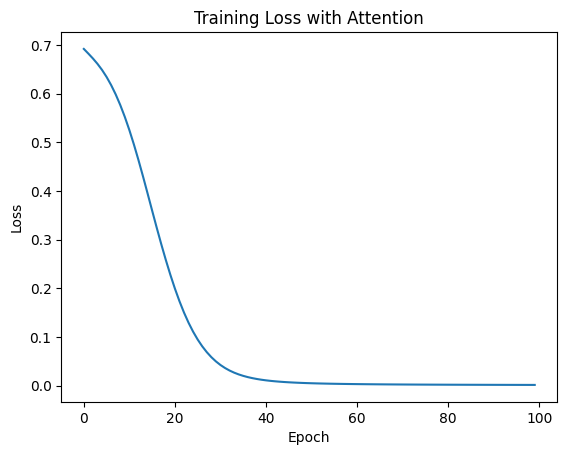

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss with Attention")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [16]:
with torch.no_grad():
    output, weights = model(padded)

sentence_idx = 0

sentence = sentences[sentence_idx].split()

attn_weights = weights[sentence_idx].squeeze().numpy()

print("Word Attention Weights:\n")
for word, weight in zip(sentence, attn_weights):
    print(f"{word:10s} → {weight:.4f}")

word_weights = list(zip(sentence, attn_weights[:len(sentence)]))
word_weights.sort(key=lambda x: x[1], reverse=True)

print("\nSorted by importance:\n")
for word, weight in word_weights:
    print(f"{word:10s} → {weight:.4f}")

Word Attention Weights:

i          → 0.0104
love       → 0.0401
nlp        → 0.9495

Sorted by importance:

nlp        → 0.9495
love       → 0.0401
i          → 0.0104


---

# Limitations

- Still depends on LSTM
- Sequential → slow
- Not fully parallelizable

---

# Mini Summary

* Attention assigns importance to words
* Solves long-distance dependency problem
* Works with LSTM to improve performance
* Foundation of Transformers

---

# Connection to Previous Notebook

* Before: LSTM → tries to remember everything
* Now: Attention → focuses on important parts

---